# EDA — Mortalidade Geral no Brasil (DATASUS/SIM, 2016-2026)

**Responsável:** Levi Lima (P3) · **Grupo 6 — AI Talent Academy (White Cube)**

Base de dados já limpa e validada pelo P2 (24/24 checagens de qualidade — ver
`data/dictionary/dicionario_dados.md`). Esta análise parte direto dos arquivos
em `data/processed/mortalidade_geral/`, sem reprocessar os dados brutos.

**Perguntas de negócio exploradas** (definidas no alinhamento do grupo):
1. Quais são as principais causas de óbito (capítulos CID-10) no período?
2. Como o total de óbitos evoluiu ano a ano?
3. Existe tendência de crescimento/queda ao longo da série?
4. Como os óbitos variam por faixa etária e por sexo?
5. Existe diferença relevante entre regiões/UFs?

## 1. Imports e configuração

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

DATA_DIR = "../data/processed/mortalidade_geral"

## 2. Carregando os dados

Cinco arquivos processados + a tabela de referência dos capítulos CID-10.

In [2]:
fato = pd.read_csv(f"{DATA_DIR}/fato_obitos.csv")
causas = pd.read_csv(f"{DATA_DIR}/capitulo_cid10_long.csv")
faixa_etaria = pd.read_csv(f"{DATA_DIR}/faixa_etaria.csv")
sexo = pd.read_csv(f"{DATA_DIR}/sexo.csv")
local = pd.read_csv(f"{DATA_DIR}/local_ocorrencia.csv")
referencia_cid10 = pd.read_csv(f"{DATA_DIR}/referencia_cid10.csv")

print("fato_obitos:", fato.shape)
print("capitulo_cid10_long:", causas.shape)
print("faixa_etaria:", faixa_etaria.shape)
print("sexo:", sexo.shape)
print("local_ocorrencia:", local.shape)
print("referencia_cid10:", referencia_cid10.shape)

fato_obitos: (352, 6)
capitulo_cid10_long: (7392, 9)
faixa_etaria: (352, 20)
sexo: (352, 10)
local_ocorrencia: (352, 13)
referencia_cid10: (22, 3)


## 3. Visão geral das tabelas

In [3]:
fato.info()

<class 'pandas.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ano           352 non-null    int64
 1   nivel         352 non-null    str  
 2   regiao        352 non-null    str  
 3   uf            297 non-null    str  
 4   sigla         297 non-null    str  
 5   total_obitos  352 non-null    int64
dtypes: int64(2), str(4)
memory usage: 16.6 KB


In [4]:
fato.describe()

,ano,total_obitos
count,352,352
mean,"2,021","86,713"
std,3,"133,951"
min,"2,016","1,034"
25%,"2,018","16,730"
50%,"2,021","34,794"
75%,"2,024","92,934"
max,"2,026","843,734"


`fato_obitos` tem 352 linhas: 32 combinações de região/UF × 11 anos (2016-2026).
Cada linha soma os óbitos de todo o Brasil para aquele recorte geográfico/ano.
Para não contar óbitos em dobro, as análises abaixo usam **apenas `nivel ==
"Estado"`** quando o total precisa ser exato para o Brasil (27 UFs), e
**`nivel == "Regiao"`** quando o recorte é por região.

In [5]:
brasil_uf = fato[fato["nivel"] == "Estado"].copy()
brasil_regiao = fato[fato["nivel"] == "Regiao"].copy()

print("Anos disponíveis:", sorted(brasil_uf["ano"].unique()))
print("UFs:", brasil_uf["uf"].nunique(), "| Regiões:", brasil_regiao["regiao"].nunique())

Anos disponíveis: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
UFs: 27 | Regiões: 5


**Ponto de atenção:** conforme o dicionário de dados, **2025 é dado
preliminar e 2026 é 1ª prévia** — ambos sujeitos a revisão pelo DATASUS.
Nos gráficos de série temporal, esses dois anos aparecem destacados para
não serem lidos como queda real de óbitos.

## 4. Pergunta 1 — Principais causas de óbito (capítulos CID-10)

In [6]:
causas_total = (
    causas.groupby(["capitulo", "descricao"], as_index=False)["obitos"]
    .sum()
    .sort_values("obitos", ascending=False)
)
top10_causas = causas_total.head(10)
top10_causas

,capitulo,descricao,obitos
4,Cap IX,"Doenças do aparelho circulatório (ex: Infarto,...",7786246
1,Cap II,Neoplasias (tumores e cânceres),4985096
9,Cap X,Doenças do aparelho respiratório (ex: Pneumoni...,3446284
19,Cap XX,Causas externas de morbidade e mortalidade (ex...,3155096
0,Cap I,Algumas doenças infecciosas e parasitárias,2687950
3,Cap IV,"Doenças endócrinas, nutricionais e metabólicas...",1806530
18,Cap XVIII,"Sintomas, sinais e achados anormais de exames ...",1595558
10,Cap XI,Doenças do aparelho digestivo,1508416
13,Cap XIV,Doenças do aparelho geniturinário,1060358
6,Cap VI,Doenças do sistema nervoso,1024802


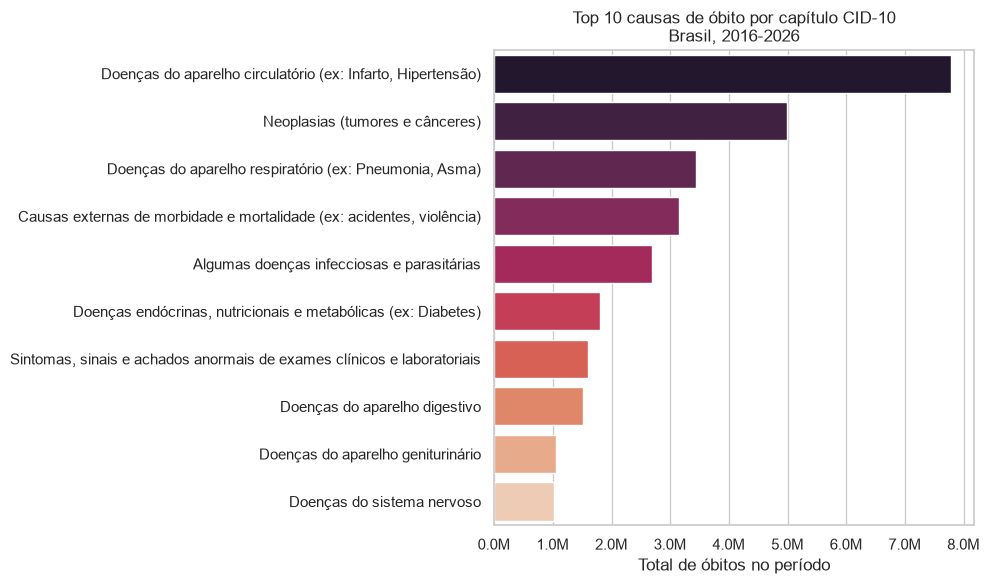

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top10_causas,
    y="descricao",
    x="obitos",
    hue="descricao",
    palette="rocket",
    legend=False,
    ax=ax,
)
ax.set_title("Top 10 causas de óbito por capítulo CID-10\nBrasil, 2016-2026")
ax.set_xlabel("Total de óbitos no período")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
fig.tight_layout()
fig.savefig("../reports/mortalidade_geral/fig_top_causas_cid10.png")
plt.show()

**Leitura:** doenças do aparelho circulatório (Cap IX — infarto, hipertensão,
AVC) lideram como causa de óbito no Brasil no período, seguidas por
neoplasias (Cap II — cânceres) e doenças do aparelho respiratório (Cap X).
Juntas, essas três categorias concentram a maior parte dos óbitos com causa
definida — um padrão coerente com o perfil epidemiológico brasileiro de
doenças crônicas não transmissíveis.

## 5. Pergunta 2 — Evolução do total de óbitos por ano

In [8]:
serie_anual = brasil_uf.groupby("ano", as_index=False)["total_obitos"].sum()
serie_anual["preliminar"] = serie_anual["ano"] >= 2025
serie_anual

,ano,total_obitos,preliminar
0,2016,1309774,False
1,2017,1312663,False
2,2018,1316719,False
3,2019,1349801,False
4,2020,1556824,False
5,2021,1832649,False
6,2022,1544266,False
7,2023,1465610,False
8,2024,1532015,False
9,2025,1534588,True


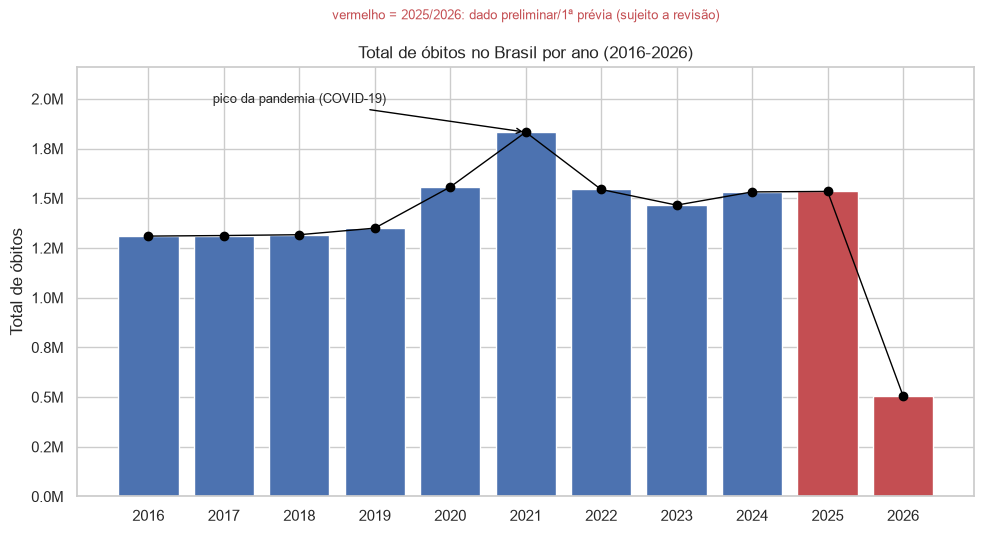

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
cores = ["#c44e52" if p else "#4c72b0" for p in serie_anual["preliminar"]]
ax.bar(serie_anual["ano"].astype(str), serie_anual["total_obitos"], color=cores)
ax.plot(serie_anual["ano"].astype(str), serie_anual["total_obitos"], color="black", marker="o", linewidth=1)
ax.set_title("Total de óbitos no Brasil por ano (2016-2026)")
ax.set_ylabel("Total de óbitos")
ax.set_ylim(0, serie_anual["total_obitos"].max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
pico_valor = serie_anual.loc[serie_anual["ano"] == 2021, "total_obitos"].values[0]
ax.annotate(
    "pico da pandemia (COVID-19)",
    xy=("2021", pico_valor), xytext=("2018", pico_valor * 1.08),
    ha="center", fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
)
ax.text(0.5, 1.11, "vermelho = 2025/2026: dado preliminar/1ª prévia (sujeito a revisão)",
        transform=ax.transAxes, ha="center", fontsize=9, color="#c44e52")
fig.tight_layout()
fig.savefig("../reports/mortalidade_geral/fig_serie_anual_obitos.png")
plt.show()

**Leitura:** a série mostra crescimento moderado e constante de 2016 a 2019,
um salto expressivo em **2020 e um pico em 2021** — coincidindo com a
pandemia de COVID-19 — e volta a um patamar mais próximo da tendência
pré-pandemia a partir de 2022. A queda aparente em 2025/2026 é efeito de
dado incompleto (preliminar/1ª prévia), não uma queda real de óbitos.

## 6. Pergunta 3 — Tendência da série (variação ano a ano)

In [10]:
serie_anual["variacao_pct"] = serie_anual["total_obitos"].pct_change() * 100
serie_anual[["ano", "total_obitos", "variacao_pct"]]

,ano,total_obitos,variacao_pct
0,2016,1309774,NaN
1,2017,1312663,0
2,2018,1316719,0
3,2019,1349801,3
4,2020,1556824,15
5,2021,1832649,18
6,2022,1544266,-16
7,2023,1465610,-5
8,2024,1532015,5
9,2025,1534588,0


**Leitura:** como a base é consolidada em nível **anual**, não é possível
avaliar sazonalidade dentro do ano (isso exigiria dado mensal, que o TabNet
não fornece nesse recorte). O que dá pra observar é a **tendência entre
anos**: crescimento de ~2-3% ao ano no período pré-pandemia, salto de
**+18% em 2020** puxado pela COVID-19, e estabilização depois — condizente
com o efeito de uma crise sanitária pontual sobre uma tendência de fundo já
crescente (população envelhecendo, crescimento vegetativo).

## 7. Pergunta 4 — Distribuição por faixa etária e sexo

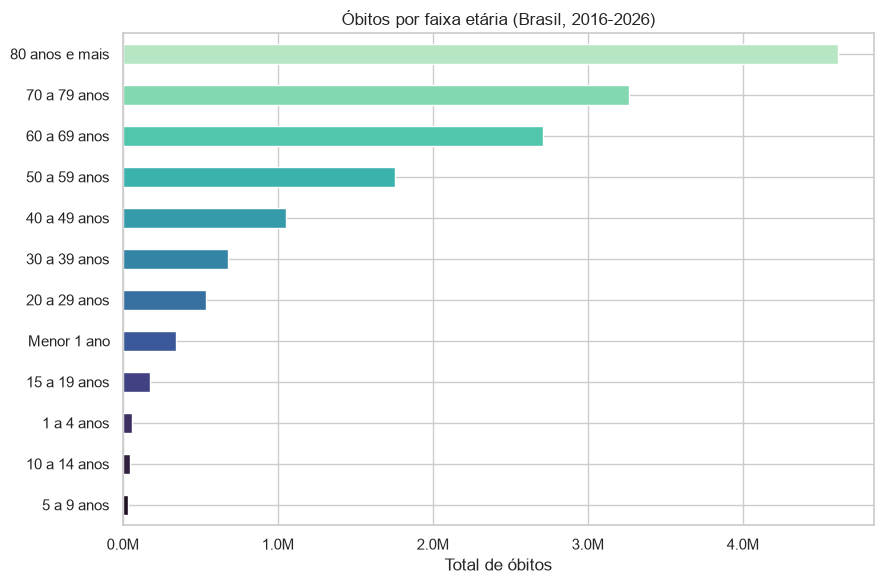

In [11]:
faixas_cols = [c for c in faixa_etaria.columns if c not in
               ["ano", "dimensao", "nivel", "regiao", "uf", "sigla", "Total", "Idade ignorada"]]
faixa_brasil = faixa_etaria[faixa_etaria["nivel"] == "Estado"][faixas_cols].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
faixa_brasil.plot(kind="barh", ax=ax, color=sns.color_palette("mako", len(faixa_brasil)))
ax.set_title("Óbitos por faixa etária (Brasil, 2016-2026)")
ax.set_xlabel("Total de óbitos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
fig.tight_layout()
fig.savefig("../reports/mortalidade_geral/fig_faixa_etaria.png")
plt.show()

**Leitura:** a mortalidade se concentra fortemente em **80 anos ou mais**,
seguida de 70-79 anos — esperado numa população que envelhece. Vale notar
um segundo ponto de atenção nos extremos: "menor 1 ano" tem volume bem
acima das faixas infantis seguintes (mortalidade infantil concentrada no
primeiro ano de vida), um recorte que pode valer aprofundar depois.

In [12]:
sexo_brasil = sexo[sexo["nivel"] == "Estado"][["Masc", "Fem", "Ign"]].sum()
sexo_pct = (sexo_brasil / sexo_brasil.sum() * 100).round(1)
sexo_pct

Masc   55
Fem    45
Ign     0
dtype: float64

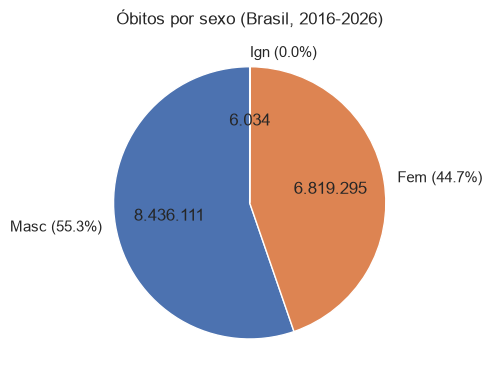

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
cores_sexo = ["#4c72b0", "#dd8452", "#bbbbbb"]
ax.pie(
    sexo_brasil[sexo_brasil > 0],
    labels=[f"{i} ({sexo_pct[i]}%)" for i in sexo_brasil[sexo_brasil > 0].index],
    colors=cores_sexo[: (sexo_brasil > 0).sum()],
    autopct=lambda p: f"{p/100*sexo_brasil.sum():,.0f}".replace(",", "."),
    startangle=90,
)
ax.set_title("Óbitos por sexo (Brasil, 2016-2026)")
fig.tight_layout()
fig.savefig("../reports/mortalidade_geral/fig_sexo.png")
plt.show()

**Leitura:** óbitos de homens representam a maioria (~55%) contra ~45% de
mulheres, uma diferença consistente com indicadores de saúde pública
brasileiros (maior exposição a causas externas e menor procura por serviços
de saúde entre homens). A parcela "ignorado" é residual (~0%).

## 8. Pergunta 5 — Diferença entre regiões e UFs

In [14]:
regiao_total = brasil_regiao.groupby("regiao", as_index=False)["total_obitos"].sum().sort_values(
    "total_obitos", ascending=False
)
regiao_total

,regiao,total_obitos
3,Região Sudeste,6919469
1,Região Nordeste,3967583
4,Região Sul,2351560
0,Região Centro-Oeste,1038149
2,Região Norte,984679


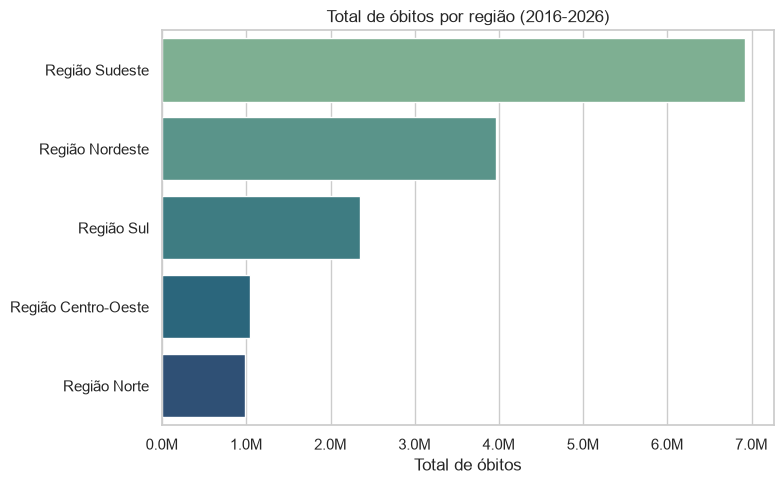

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=regiao_total, x="total_obitos", y="regiao", hue="regiao",
            palette="crest", legend=False, ax=ax)
ax.set_title("Total de óbitos por região (2016-2026)")
ax.set_xlabel("Total de óbitos")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
fig.tight_layout()
fig.savefig("../reports/mortalidade_geral/fig_regiao.png")
plt.show()

**Leitura:** Sudeste concentra o maior número absoluto de óbitos, seguido
do Nordeste — o que reflete, antes de tudo, o **tamanho da população** de
cada região, não necessariamente maior risco de morte. Sem dado de
população por UF/ano nesta base, não dá pra calcular taxa de mortalidade
(óbitos por 100 mil habitantes) — isso fica registrado como limitação e
como sugestão de melhoria (ver seção 9).

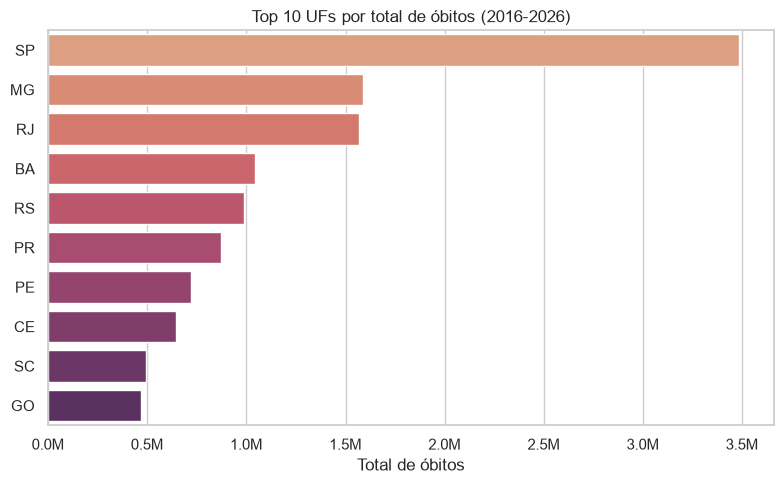

In [16]:
top10_uf = brasil_uf.groupby(["uf", "sigla"], as_index=False)["total_obitos"].sum().sort_values(
    "total_obitos", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10_uf, x="total_obitos", y="sigla", hue="sigla",
            palette="flare", legend=False, ax=ax)
ax.set_title("Top 10 UFs por total de óbitos (2016-2026)")
ax.set_xlabel("Total de óbitos")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
fig.tight_layout()
fig.savefig("../reports/mortalidade_geral/fig_top_uf.png")
plt.show()

**Leitura:** São Paulo lidera com folga (maior população do país), seguido
por Minas Gerais, Rio de Janeiro e Bahia — o ranking por total absoluto
segue essencialmente o ranking populacional das UFs.

## 9. Principais achados

1. **Causas de óbito:** doenças do aparelho circulatório, neoplasias e
   doenças respiratórias são as três maiores causas de óbito no Brasil no
   período — juntas concentram a maior parte dos óbitos com causa
   definida. Recomendação para o P4: esses 3 capítulos merecem destaque
   fixo no dashboard (ex.: KPI cards ou top N sempre visível).
2. **Série temporal:** a pandemia de COVID-19 gerou um salto atípico de
   óbitos em 2020-2021 (+18% em 2020 sobre 2019) sobre uma tendência de
   fundo já crescente. 2025 e 2026 são dados preliminares/prévia e **não
   devem ser lidos como queda real** — o P4 deve marcar visualmente esses
   dois anos como "dado sujeito a revisão" no dashboard.
3. **Tendência/sazonalidade:** a granularidade da base é anual, então não
   dá pra avaliar sazonalidade intra-ano; a análise de tendência foi feita
   ano a ano.
4. **Faixa etária e sexo:** óbitos concentrados em 70+ anos (esperado numa
   população envelhecendo); homens são maioria dos óbitos (~55%) —
   ambos os recortes são bons filtros/segmentações para o dashboard.
5. **Regiões/UFs:** Sudeste e São Paulo lideram em volume absoluto, mas
   isso reflete principalmente o tamanho da população, não
   necessariamente maior risco de morte. **Limitação relevante:** a base
   não tem dado de população, então não é possível calcular taxa de
   mortalidade (óbitos por 100 mil habitantes) — sugestão para uma
   próxima iteração é cruzar com dado populacional do IBGE para permitir
   comparação justa entre UFs.

**Limitações gerais da base para registro:**
- 2025 (preliminar) e 2026 (1ª prévia) sujeitos a revisão pelo DATASUS.
- Sem dado de população — comparações regionais são só em volume
  absoluto, não em taxa.
- Cap XIX (lesões/envenenamento) só aparece em 2023 e Cap XXII (códigos
  especiais, ex. COVID-19) só em 2026 — colunas zeradas nos demais anos
  por ausência real de ocorrência registrada nesse recorte, não erro de
  dado (ver `data/dictionary/dicionario_dados.md`).